## Import Packages

In [2]:
from tqdm import tqdm
import torch
import torch.nn as nn 

from torch import optim
from torch.utils.data import DataLoader

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid

## Hyper Parameters Settings

In [3]:
lr = 0.0001
batch_size = 64
num_epoch = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu'


## Datasets Preparation

In [4]:
image_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
mnist_datasets =  MNIST('./data', train=True, download=True, transform=image_transforms)

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.59MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [6]:
mnist_dataloader = DataLoader(mnist_datasets, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
next(iter(mnist_dataloader))[0].shape

torch.Size([64, 1, 28, 28])

### Model Building

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        ## ENcoder type model
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [9]:
discriminator = Discriminator()
img = torch.randn(10, 784)
discriminator(img).shape

torch.Size([10, 1])

In [10]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # random noise 100 length 
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, x):
        return self.model(x)

In [11]:
generator = Generator()
generator(torch.randn(10, 100)).shape

torch.Size([10, 784])

In [12]:
def noise(batch_size, device):
    return torch.randn(batch_size, 100).to(device=device)

noise(64, 'cuda').shape

torch.Size([64, 100])

### Model Configuratoin

In [13]:
discriminator = Discriminator().to(device=device)
generator = Generator().to(device=device)
criteria = nn.BCELoss()
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)
g_optimizer = optim.Adam(generator.parameters(), lr=lr)


In [14]:
def train_discriminator(discriminator, criteria, d_optimizer, real_image, fake_image, device):
    discriminator.train()
    d_optimizer.zero_grad()

    ## Forward pass for Real Image
    real_output =  discriminator(real_image)
    real_loss = criteria(real_output, torch.ones(len(real_output), 1).to(device=device))
    real_loss.backward()

    ## Forward Pass for Fake Image
    fake_output =  discriminator(fake_image)
    fake_loss = criteria(fake_output, torch.zeros(len(fake_output), 1).to(device=device))
    fake_loss.backward()

    d_optimizer.step()
    return real_loss + fake_loss
    


In [15]:
def train_generator(discriminator, criteria, g_optimizer, fake_image, device):
    g_optimizer.zero_grad()
    output = discriminator(fake_image)
    loss = criteria(output, torch.ones(len(output), 1).to(device=device))
    loss.backward()
    g_optimizer.step()
    return loss

In [16]:
total_gen_loss, total_disc_loss = [] , []
for epoch in range(1, num_epoch + 1):
    epoch_gen_loss, epoch_desc_loss = 0, 0
    for images, _ in tqdm(mnist_dataloader, desc=f"Training {epoch} of {num_epoch}"):
        real_image = images.view(len(images), -1).to(device=device)
        fake_image = generator(noise(len(images), device=device))

        disc_loss = train_discriminator(discriminator, criteria, d_optimizer, real_image, fake_image, device)

        fake_image = generator(noise(len(images), device=device))
        gen_loss = train_generator(discriminator, criteria, g_optimizer, fake_image, device)
    
        epoch_gen_loss = epoch_gen_loss + gen_loss.item()
        epoch_desc_loss = epoch_desc_loss + disc_loss.item()
    print("Generator Loss: ", epoch_gen_loss, "Discriminator Loss; ", epoch_desc_loss)
    total_gen_loss.append(epoch_gen_loss)
    total_disc_loss.append(epoch_desc_loss)
    

Training 1 of 100: 100%|██████████| 938/938 [00:10<00:00, 85.31it/s]


Generator Loss:  1731.3712452203035 Discriminator Loss;  927.0558649972081


Training 2 of 100: 100%|██████████| 938/938 [00:10<00:00, 91.54it/s] 


Generator Loss:  1938.4332513213158 Discriminator Loss;  743.4758221767843


Training 3 of 100: 100%|██████████| 938/938 [00:10<00:00, 90.91it/s]


...

Generator Loss:  891.5251584649086 Discriminator Loss;  1158.6931374073029


Training 99 of 100: 100%|██████████| 938/938 [00:10<00:00, 92.10it/s]


Generator Loss:  884.2581892609596 Discriminator Loss;  1162.0626819133759


Training 100 of 100: 100%|██████████| 938/938 [00:10<00:00, 90.96it/s] 

Generator Loss:  881.2639383077621 Discriminator Loss;  1164.6301466226578


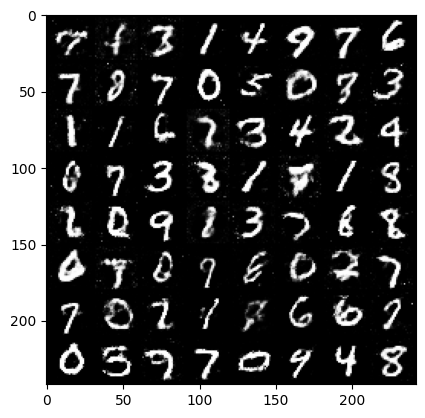

In [18]:
z = torch.randn(64, 100).to(device)
sample_images = generator(z).data.cpu().view(64, 1, 28, 28)
grid = make_grid(sample_images, nrow=8, normalize=True)

import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(grid.cpu().detach().permute(1,2,0))

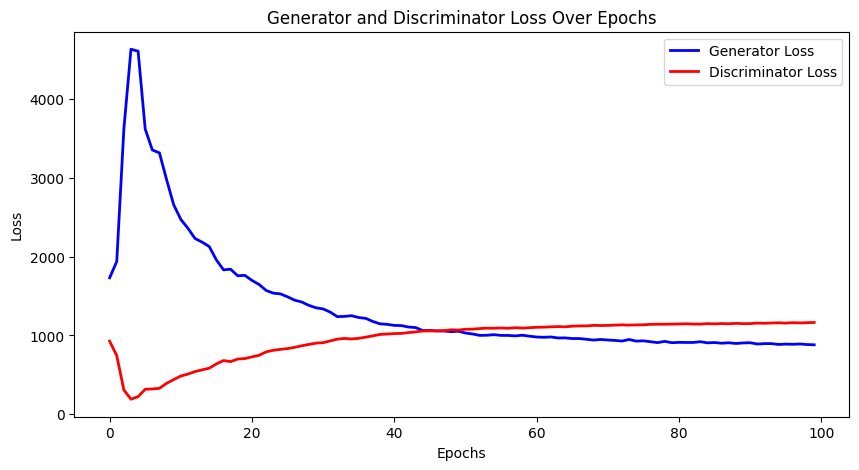

In [19]:
import matplotlib.pyplot as plt

# Your training loop here...

# After the training loop
plt.figure(figsize=(10, 5))

# Plot Generator Loss
plt.plot(total_gen_loss, label='Generator Loss', color='blue', linewidth=2)

# Plot Discriminator Loss
plt.plot(total_disc_loss, label='Discriminator Loss', color='red', linewidth=2)

# Add labels and title
plt.title('Generator and Discriminator Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plot
plt.show()
